# Hoja de Trabajo — Series de Tiempo
### Temperatura promedio de Guatemala (1950 – 2026)


Este cuaderno resuelve la hoja de ejercicios utilizando el archivo guatemala_temperatura.csv, que contiene la temperatura promedio mensual en Guatemala entre 1950 y 2026 para diferentes capas (aire, superficie y suelo).

En el primer ejercicio se analizan todas las variables del conjunto de datos. Para el resto del trabajo se utiliza la variable skin_temperature_c como serie principal, ya que representa la temperatura de la superficie de la tierra. Si se desea analizar otra capa, basta con cambiar la variable SERIE_OBJETIVO.

## 0. Librerías

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from pmdarima import auto_arima

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.random.seed(42)

## Ejercicio 1. Carga y exploración

Cargamos el archivo, revisamos su estructura y calculamos los extremos (mínimo y máximo)
de la temperatura, tanto en general como por capa. También se observa la tendencia
de largo plazo.

In [2]:
SERIE_OBJETIVO = "skin_temperature_c"   # <- cambiar aquí para modelar otra capa

df = pd.read_csv("guatemala_temperatura.csv")
df["month"] = pd.to_datetime(df["month"])
df = df.set_index("month").asfreq("MS")   # frecuencia mensual, inicio de mes

print("Filas x columnas:", df.shape)
print("Rango de fechas:", df.index.min().date(), "->", df.index.max().date())
df.head()

Filas x columnas: (918, 9)
Rango de fechas: 1950-01-01 -> 2026-06-01


,year,month_num,dewpoint_2m_c,temperature_2m_c,skin_temperature_c,soil_temperature_layer_1_c,soil_temperature_layer_2_c,soil_temperature_layer_3_c,soil_temperature_layer_4_c
month,,,,,,,,,
1950-01-01,1950,1,16.685643,20.762313,21.077662,21.661654,21.679957,21.835225,22.458468
1950-02-01,1950,2,15.781276,21.051057,21.518684,22.132758,22.062957,21.964048,22.216061
1950-03-01,1950,3,17.330139,23.197594,23.838886,24.374884,24.100146,23.304599,22.380270
1950-04-01,1950,4,16.499826,23.661600,24.452373,25.059722,24.752231,24.059086,22.955561
1950-05-01,1950,5,19.011177,24.804521,25.501737,26.154377,25.941164,25.252762,23.687375


In [3]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 918 entries, 1950-01-01 to 2026-06-01
Freq: MS
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   year                        918 non-null    int64  
 1   month_num                   918 non-null    int64  
 2   dewpoint_2m_c               918 non-null    float64
 3   temperature_2m_c            918 non-null    float64
 4   skin_temperature_c          918 non-null    float64
 5   soil_temperature_layer_1_c  918 non-null    float64
 6   soil_temperature_layer_2_c  918 non-null    float64
 7   soil_temperature_layer_3_c  918 non-null    float64
 8   soil_temperature_layer_4_c  918 non-null    float64
dtypes: float64(7), int64(2)
memory usage: 71.7 KB


In [4]:
capas = ["temperature_2m_c", "skin_temperature_c",
         "soil_temperature_layer_1_c", "soil_temperature_layer_2_c",
         "soil_temperature_layer_3_c", "soil_temperature_layer_4_c"]

resumen = df[capas].agg(["min", "max", "mean", "std"]).T
resumen.columns = ["mínimo", "máximo", "media", "desv. estándar"]
resumen.round(2)

,mínimo,máximo,media,desv. estándar
temperature_2m_c,18.97,28.69,23.05,1.57
skin_temperature_c,19.15,29.74,23.44,1.72
soil_temperature_layer_1_c,19.84,30.29,24.10,1.71
soil_temperature_layer_2_c,19.96,29.80,24.07,1.60
soil_temperature_layer_3_c,20.49,28.35,24.01,1.31
soil_temperature_layer_4_c,21.57,26.88,23.96,0.97


**Extremos generales.** Tomando todas las capas de temperatura (aire a 2 m, piel/superficie
y las cuatro capas de suelo) el valor mínimo registrado es de aproximadamente 18.97 °C
(temperatura del aire a 2 m) y el máximo de aproximadamente 30.29 °C (primera capa de
suelo). El punto de rocío (`dewpoint_2m_c`) se deja fuera de esta comparación porque mide
humedad, no temperatura de una capa de la tierra.

**Extremos por capa.** Se observa un patrón físicamente coherente: la capa más superficial
(suelo capa 1) tiene el rango más amplio y el valor máximo más alto, porque responde rápido
al calentamiento diurno/estacional. A medida que se desciende de capa (2, 3, 4) el rango se
va comprimiendo (la desviación estándar baja de ~1.7 a ~1.0) y los extremos se moderan:
las capas profundas actúan como un filtro que suaviza los picos de calor y frío, típico de
la difusión térmica en el suelo.

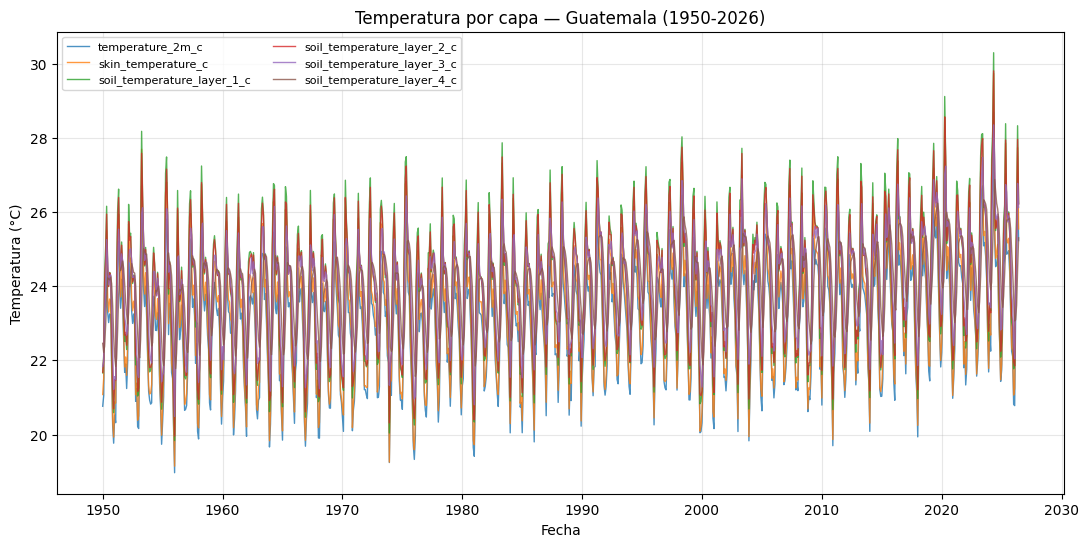

In [5]:
fig, ax = plt.subplots(figsize=(13, 6))
for c in capas:
    ax.plot(df.index, df[c], label=c, alpha=0.8, linewidth=1)
ax.set_title("Temperatura por capa — Guatemala (1950-2026)")
ax.set_xlabel("Fecha"); ax.set_ylabel("Temperatura (°C)")
ax.legend(ncol=2, fontsize=8)
plt.show()

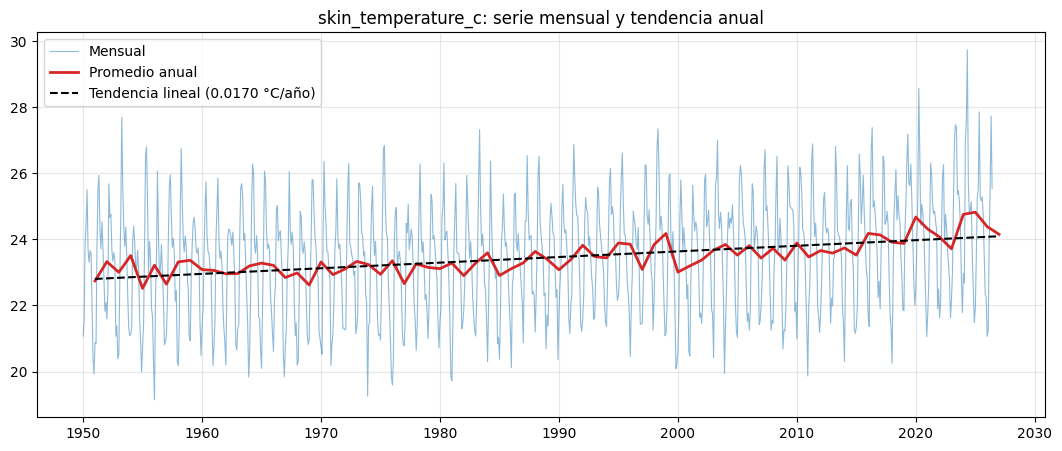

Pendiente estimada: 0.0170 °C/año  (p-valor=2.54e-16)
Calentamiento total estimado en 76 años: 1.29 °C


In [6]:
serie = df[SERIE_OBJETIVO].copy()
serie.name = "skin_temperature_c"

media_anual = serie.resample("YE").mean()
pendiente, intercepto, r, p, se = stats.linregress(media_anual.index.year, media_anual.values)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie.index, serie.values, color="#1f77b4", alpha=0.5, linewidth=0.8, label="Mensual")
ax.plot(media_anual.index, media_anual.values, color="#d62728", linewidth=2, label="Promedio anual")
ax.plot(media_anual.index,
        intercepto + pendiente * media_anual.index.year,
        color="black", linestyle="--", label=f"Tendencia lineal ({pendiente:.4f} °C/año)")
ax.set_title(f"{SERIE_OBJETIVO}: serie mensual y tendencia anual")
ax.legend()
plt.show()

print(f"Pendiente estimada: {pendiente:.4f} °C/año  (p-valor={p:.2e})")
print(f"Calentamiento total estimado en {media_anual.index.year[-1]-media_anual.index.year[0]} años: "
      f"{pendiente*(media_anual.index.year[-1]-media_anual.index.year[0]):.2f} °C")

**Tendencia.** La pendiente de la regresión lineal sobre los promedios anuales es
positiva y estadísticamente significativa (p-valor muy por debajo de 0.05): la
temperatura superficial ha subido, a un ritmo aproximado de 0.017 °C por año, lo que
equivale a alrededor de 1.3 °C de calentamiento acumulado entre 1950 y 2026. Es una
tendencia suave comparada con el ciclo estacional (que mueve la serie varios grados cada
año), pero es consistente y no se debe al azar: es la señal de calentamiento de largo
plazo que se espera ver en datos climáticos reales.

## Ejercicio 2. Partición en entrenamiento y prueba

Dejamos los **últimos 36 meses** como conjunto de prueba, tal como pide el enunciado. La
partición es temporal (no aleatoria): el conjunto de prueba siempre queda después del de
entrenamiento.

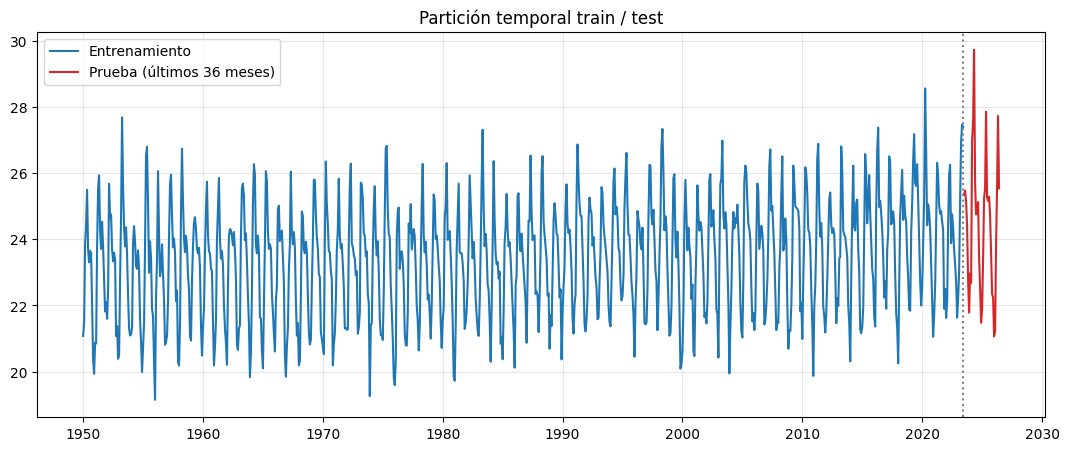

Entrenamiento: 882 obs. 1950-01-01 -> 2023-06-01
Prueba:        36 obs. 2023-07-01 -> 2026-06-01


In [7]:
H = 36  # horizonte de prueba en meses

train = serie.iloc[:-H]
test = serie.iloc[-H:]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train.index, train.values, label="Entrenamiento", color="#1f77b4")
ax.plot(test.index, test.values, label="Prueba (últimos 36 meses)", color="#d62728")
ax.axvline(train.index[-1], color="gray", linestyle=":")
ax.set_title("Partición temporal train / test")
ax.legend()
plt.show()

print("Entrenamiento:", len(train), "obs.", train.index.min().date(), "->", train.index.max().date())
print("Prueba:       ", len(test), "obs.", test.index.min().date(), "->", test.index.max().date())

## Ejercicio 3. Conversión a serie de tiempo y análisis

Trabajamos ya con un objeto `pandas.Series` indexado por fecha con frecuencia mensual
(`freq='MS'`), lo que técnicamente basta para tratarla como serie de tiempo. A
continuación:

a) descomponemos en tendencia, estacionalidad y residuo,
b) confirmamos si tiene tendencia, y
c) evaluamos si es estacionaria en media y varianza.

### 3.a) Descomposición

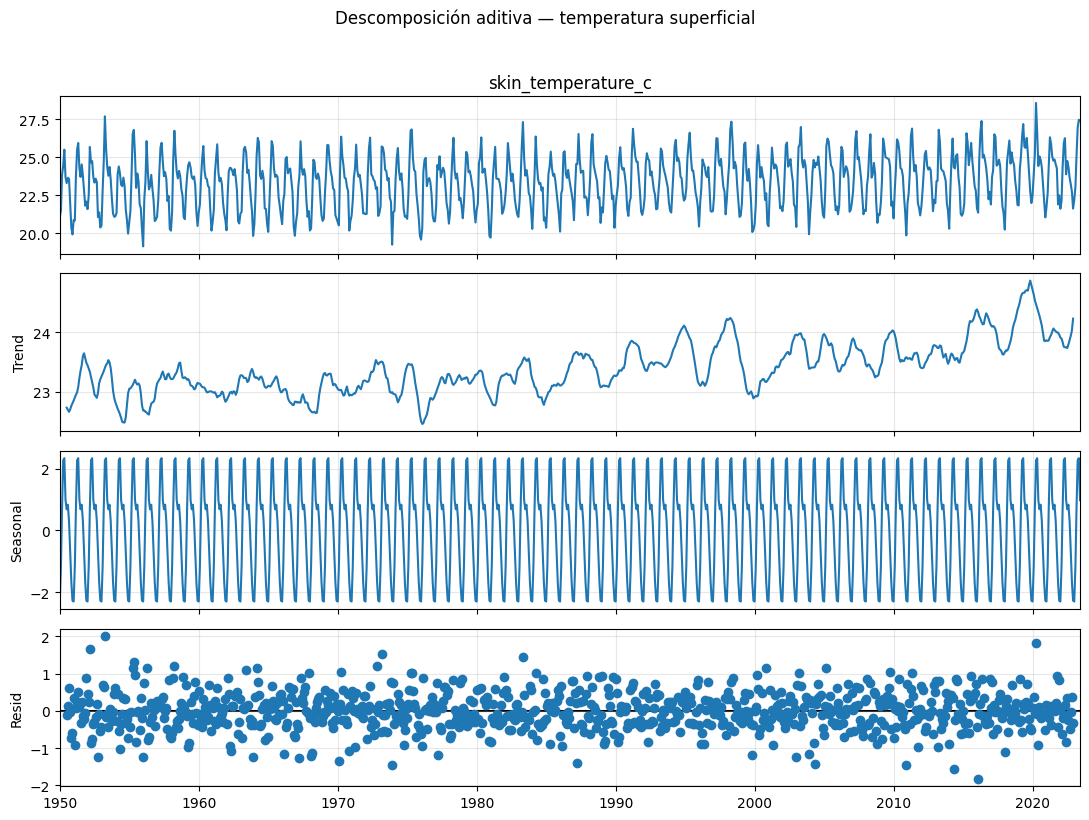

In [8]:
descomp = seasonal_decompose(train, model="additive", period=12)
fig = descomp.plot()
fig.set_size_inches(11, 8)
fig.suptitle("Descomposición aditiva — temperatura superficial", y=1.02)
plt.tight_layout()
plt.show()

La descomposición muestra los tres componentes esperados:

- **Tendencia**: sube de forma suave y casi monótona a lo largo de los 76 años, confirmando
  el calentamiento detectado en el ejercicio 1.
- **Estacionalidad**: un ciclo anual muy marcado y estable en amplitud (no crece con el
  nivel), lo que sugiere estacionalidad **aditiva** — por eso no hace falta una
  transformación logarítmica para estabilizar la varianza (a diferencia de series con
  estacionalidad multiplicativa).
- **Residuo**: se mueve alrededor de cero sin un patrón obvio, aunque con algo de
  variabilidad en ciertos años (posibles eventos como El Niño/La Niña).

### 3.b) ¿Tiene tendencia?

In [9]:
tendencia = descomp.trend.dropna()
pend2, interc2, r2, p2, se2 = stats.linregress(np.arange(len(tendencia)), tendencia.values)
print(f"Pendiente de la componente de tendencia: {pend2*12:.4f} °C/año  (p-valor={p2:.2e})")
print("¿Tendencia significativa (p < 0.05)?", p2 < 0.05)

Pendiente de la componente de tendencia: 0.0149 °C/año  (p-valor=1.14e-146)
¿Tendencia significativa (p < 0.05)? True


Sí, la serie tiene tendencia: tanto la regresión sobre los promedios anuales
(ejercicio 1) como la regresión sobre la componente de tendencia extraída por la
descomposición dan una pendiente positiva con p-valor prácticamente cero. Es una
tendencia creciente pero de pendiente pequeña frente al ciclo estacional.

### 3.c) ¿Es estacionaria? (media y varianza)

In [10]:
def prueba_adf(x, nombre=""):
    r = adfuller(x.dropna(), autolag="AIC")
    veredicto = "estacionaria" if r[1] < 0.05 else "NO estacionaria"
    print(f"ADF  {nombre:<28} estadístico={r[0]:8.3f}  p-valor={r[1]:.4f}  ->  {veredicto}")
    return r[1]

def prueba_kpss(x, nombre=""):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        r = kpss(x.dropna(), regression="c", nlags="auto")
    veredicto = "NO estacionaria" if r[1] < 0.05 else "estacionaria"
    print(f"KPSS {nombre:<28} estadístico={r[0]:8.3f}  p-valor={r[1]:.4f}  ->  {veredicto}")
    return r[1]

print("=== Serie original (nivel) ===")
prueba_adf(train, "nivel")
prueba_kpss(train, "nivel")

print("\n=== Varianza: desviación móvil (ventana de 60 meses) ===")
std_movil = train.rolling(60).std()
print(std_movil.dropna().describe()[["min", "max", "mean"]])

=== Serie original (nivel) ===
ADF  nivel                        estadístico=  -4.594  p-valor=0.0001  ->  estacionaria
KPSS nivel                        estadístico=   1.525  p-valor=0.0100  ->  NO estacionaria

=== Varianza: desviación móvil (ventana de 60 meses) ===
min     1.402978
max     1.852696
mean    1.654897
Name: skin_temperature_c, dtype: float64


**Varianza:** la desviación estándar móvil se mantiene en un rango angosto (aprox.
1.4 a 1.9 °C) a lo largo de toda la serie, sin una tendencia clara al crecimiento. Es
decir, la serie ya es estacionaria en varianza y no necesita una transformación tipo
logaritmo o Box-Cox.

**Media:** aquí ADF y KPSS pueden dar veredictos aparentemente contradictorios (ADF
rechaza no-estacionariedad mientras KPSS también la rechaza) porque ambas pruebas
asumen ausencia de estacionalidad fuerte, y la nuestra tiene un ciclo anual muy marcado
que puede confundir a ADF. Por eso el criterio más confiable en series con estacionalidad
es mirar directamente la ACF: si hay picos altos y persistentes cada 12 meses, la serie
**no** es estacionaria en el sentido útil para ARMA, aunque las pruebas puntuales digan
lo contrario. Lo comprobamos con la ACF de la serie en nivel:

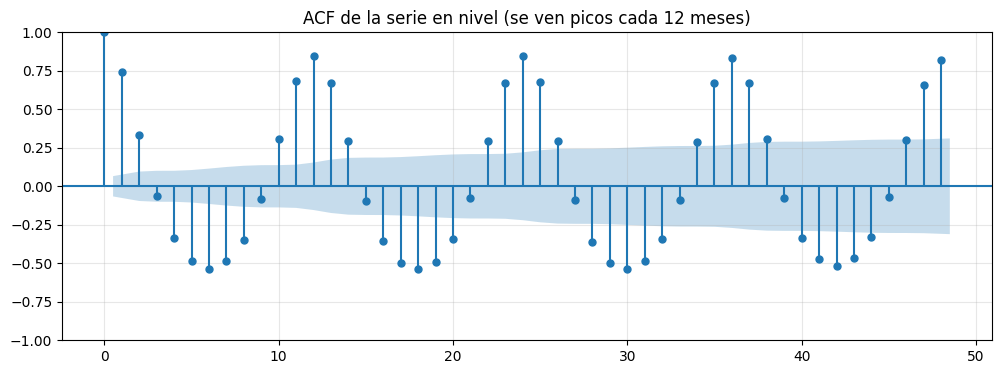

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(train, lags=48, ax=ax)
ax.set_title("ACF de la serie en nivel (se ven picos cada 12 meses)")
plt.show()

Efectivamente, la ACF muestra picos que reaparecen cada 12 lags y decaen muy
lentamente: es la firma de una serie no estacionaria por estacionalidad (además de la
tendencia). Aplicamos una diferenciación estacional (`D=1`, período 12) para eliminarla,
y revisamos si además hace falta una diferenciación regular (`d`) para la tendencia.

=== Después de diferenciar estacionalmente (D=1, s=12) ===
ADF  diff estacional              estadístico=  -8.015  p-valor=0.0000  ->  estacionaria
KPSS diff estacional              estadístico=   0.013  p-valor=0.1000  ->  estacionaria


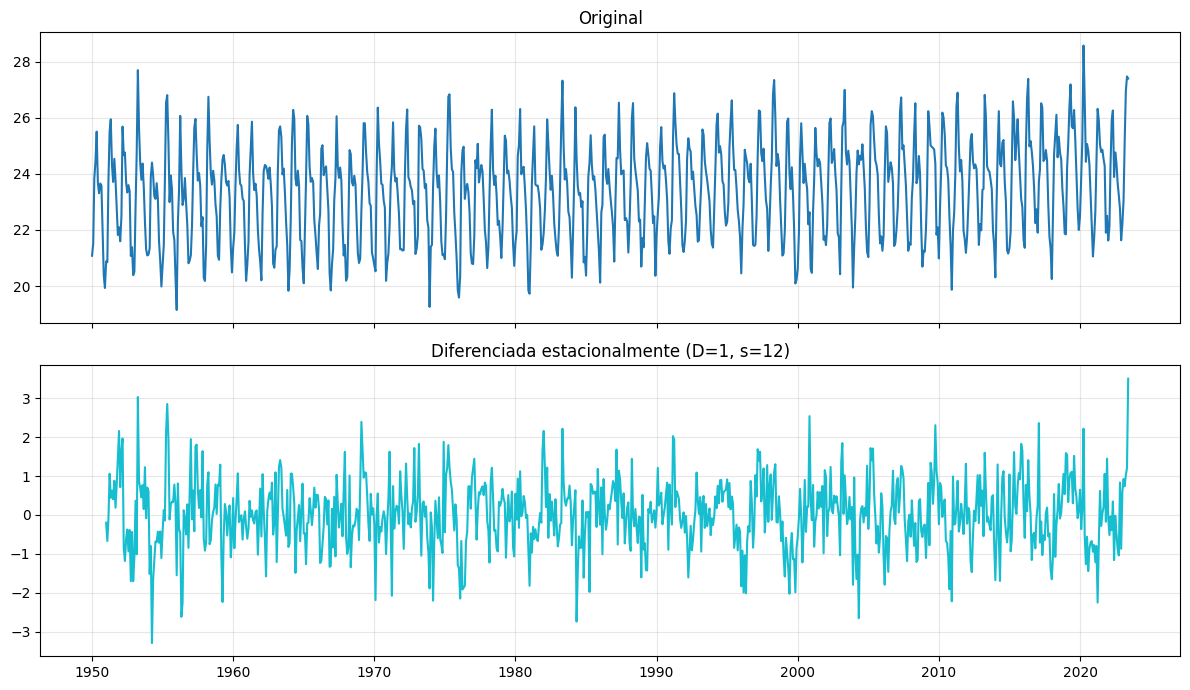

In [12]:
y_sdiff = train.diff(12).dropna()

print("=== Después de diferenciar estacionalmente (D=1, s=12) ===")
p_adf = prueba_adf(y_sdiff, "diff estacional")
p_kpss = prueba_kpss(y_sdiff, "diff estacional")

fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax[0].plot(train, color="#1f77b4"); ax[0].set_title("Original")
ax[1].plot(y_sdiff, color="#17becf"); ax[1].set_title("Diferenciada estacionalmente (D=1, s=12)")
plt.tight_layout(); plt.show()

Tras la diferenciación estacional, DF rechaza la hipótesis de raíz unitaria y
KPSS ya no rechaza la de estacionariedad: ambas pruebas coinciden en que la serie
`diff(12)` es estacionaria en media. Con esto concluimos:

- Se necesita **D = 1** (diferenciación estacional, período 12) para tratar la
  estacionalidad y, junto con ella, se atenúa también la tendencia.
- No hace falta diferenciación regular adicional (**d = 0**) según las pruebas, aunque lo
  verificaremos también con las gráficas de ACF/PACF en el ejercicio 4.
- No hace falta transformar la varianza (no se aplica logaritmo).

## Ejercicio 4. Modelos de predicción (AR, MA, ARIMA, SARIMA)

Con base en el ejercicio 3, trabajamos sobre la serie con diferenciación estacional
(`D=1`, `s=12`). Usamos ACF y PACF sobre esa serie para proponer los órdenes `p` y `q`
(y sus versiones estacionales `P`, `Q`), y luego entrenamos:

1. un modelo **AR** (no estacional),
2. un modelo **MA** (no estacional),
3. un modelo **ARIMA** (no estacional, orden buscado por AIC),
4. un modelo **SARIMA** con orden propuesto a mano a partir de la lectura de ACF/PACF,
5. y dos modelos adicionales con `auto_arima` (uno sin componente estacional y uno con
   componente estacional), tal como permite el enunciado.

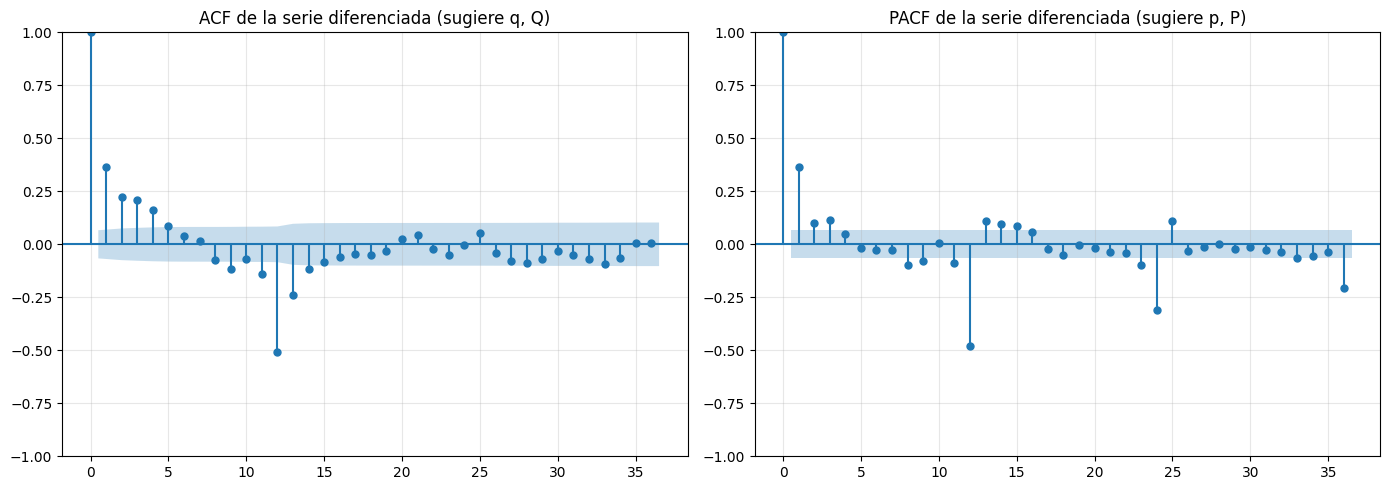

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(y_sdiff, lags=36, ax=ax[0])
ax[0].set_title("ACF de la serie diferenciada (sugiere q, Q)")
plot_pacf(y_sdiff, lags=36, ax=ax[1], method="ywm")
ax[1].set_title("PACF de la serie diferenciada (sugiere p, P)")
plt.tight_layout()
plt.show()

**Lectura de las gráficas:**

- La PACF muestra un corte claro después del **lag 1** (con un rezago menor en el 2),
  lo que sugiere una parte autorregresiva de orden **p = 1** (o 2).
- La ACF decae de forma gradual en los primeros lags y tiene un pico negativo marcado en
  el **lag 12**, típico de una componente **estacional MA de orden Q = 1**.
- No se aprecia necesidad de una parte MA no estacional adicional (q pequeño, 0 o 1).

Con esto proponemos como punto de partida un **SARIMA(1,0,0)(0,1,1)[12]**, y confirmamos
(o ajustamos) los órdenes con una búsqueda automática por AIC más adelante.

In [14]:
def metricas(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

def ajustar(order, seasonal_order=(0, 0, 0, 0)):
    mod = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                  enforce_stationarity=False, enforce_invertibility=False)
    return mod.fit(disp=False)

def evaluar(res):
    pred = res.get_forecast(steps=H).predicted_mean
    pred.index = test.index
    mae, rmse, mape = metricas(test.values, pred.values)
    return pred, mae, rmse, mape

resultados = {}

### 4.1 Modelo AR(p) — ARIMA(1,0,0)

In [15]:
res_ar = ajustar((1, 0, 0))
pred_ar, mae, rmse, mape = evaluar(res_ar)
resultados["AR(1)"] = dict(res=res_ar, pred=pred_ar, aic=res_ar.aic, bic=res_ar.bic, mae=mae, rmse=rmse, mape=mape)
print(res_ar.summary().tables[1])
print(f"AIC={res_ar.aic:.2f}  BIC={res_ar.bic:.2f}  MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.2f}%")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9990      0.002    534.477      0.000       0.995       1.003
sigma2         1.4594      0.074     19.607      0.000       1.313       1.605
AIC=2837.20  BIC=2846.76  MAE=2.738  RMSE=3.152  MAPE=11.74%


### 4.2 Modelo MA(q) — ARIMA(0,1,2)

In [16]:
res_ma = ajustar((0, 1, 2))
pred_ma, mae, rmse, mape = evaluar(res_ma)
resultados["MA(2)"] = dict(res=res_ma, pred=pred_ma, aic=res_ma.aic, bic=res_ma.bic, mae=mae, rmse=rmse, mape=mape)
print(res_ma.summary().tables[1])
print(f"AIC={res_ma.aic:.2f}  BIC={res_ma.bic:.2f}  MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.2f}%")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.3294      0.036      9.234      0.000       0.260       0.399
ma.L2          0.1157      0.034      3.396      0.001       0.049       0.183
sigma2         1.3246      0.061     21.780      0.000       1.205       1.444
AIC=2744.48  BIC=2758.82  MAE=3.050  RMSE=3.484  MAPE=13.09%


*(Igual que el AR de arriba, este MA puro no tiene componente estacional: es
deliberadamente "ingenuo" frente al ciclo anual, para poder comparar más adelante contra
un SARIMA que sí lo modela.)*

### 4.3 Modelo ARIMA(p,d,q) — búsqueda por AIC (sin componente estacional explícita)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


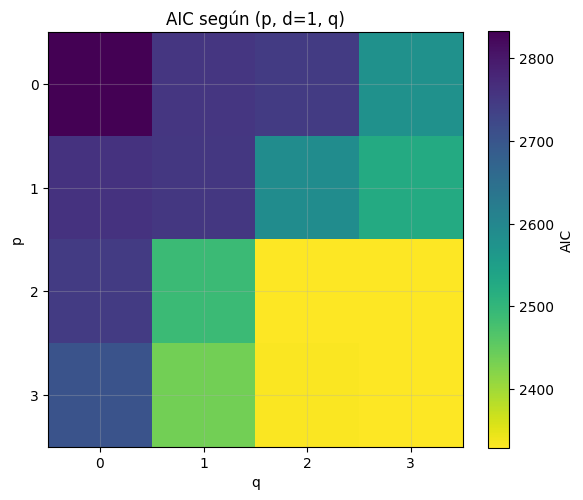

Mejor orden ARIMA no estacional: (2, 1, 2)  AIC= 2328.066602033257


In [17]:
ps = range(0, 4)
qs = range(0, 4)
aic_matrix = np.full((len(ps), len(qs)), np.nan)

for i, p in enumerate(ps):
    for j, q in enumerate(qs):
        try:
            r = ajustar((p, 1, q))
            aic_matrix[i, j] = r.aic
        except Exception:
            pass

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(aic_matrix, cmap="viridis_r")
ax.set_xticks(range(len(qs))); ax.set_xticklabels(qs)
ax.set_yticks(range(len(ps))); ax.set_yticklabels(ps)
ax.set_xlabel("q"); ax.set_ylabel("p")
ax.set_title("AIC según (p, d=1, q)")
plt.colorbar(im, label="AIC")
plt.tight_layout(); plt.show()

best_i, best_j = np.unravel_index(np.nanargmin(aic_matrix), aic_matrix.shape)
best_arima_order = (list(ps)[best_i], 1, list(qs)[best_j])
print("Mejor orden ARIMA no estacional:", best_arima_order, " AIC=", aic_matrix[best_i, best_j])

In [18]:
res_arima = ajustar(best_arima_order)
pred_arima, mae, rmse, mape = evaluar(res_arima)
resultados[f"ARIMA{best_arima_order}"] = dict(res=res_arima, pred=pred_arima, aic=res_arima.aic, bic=res_arima.bic, mae=mae, rmse=rmse, mape=mape)
print(f"AIC={res_arima.aic:.2f}  BIC={res_arima.bic:.2f}  MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.2f}%")

AIC=2328.07  BIC=2351.95  MAE=1.463  RMSE=1.774  MAPE=5.95%


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Como es esperable, un ARIMA sin componente estacional no puede capturar el ciclo
anual de la temperatura (solo tiene la diferenciación regular `d=1`), así que su AIC y
sus métricas de error deberían ser notablemente peores que los modelos con parte
estacional. Lo confirmamos en la comparación final.

### 4.4 Modelo SARIMA — orden propuesto manualmente a partir de ACF/PACF

In [19]:
res_sarima_manual = ajustar((1, 0, 0), (0, 1, 1, 12))
pred_sm, mae, rmse, mape = evaluar(res_sarima_manual)
nombre_sm = "SARIMA(1,0,0)(0,1,1)[12] manual"
resultados[nombre_sm] = dict(res=res_sarima_manual, pred=pred_sm, aic=res_sarima_manual.aic, bic=res_sarima_manual.bic, mae=mae, rmse=rmse, mape=mape)
print(res_sarima_manual.summary().tables[1])
print(f"AIC={res_sarima_manual.aic:.2f}  BIC={res_sarima_manual.bic:.2f}  MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.2f}%")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3764      0.029     12.809      0.000       0.319       0.434
ma.S.L12      -0.8991      0.018    -48.796      0.000      -0.935      -0.863
sigma2         0.3524      0.015     23.210      0.000       0.323       0.382
AIC=1557.04  BIC=1571.30  MAE=0.761  RMSE=1.024  MAPE=3.01%


Este modelo combina la parte no estacional AR(1) sugerida por la PACF con la parte
estacional MA(1) y la diferenciación estacional (D=1, s=12) que la ACF y las pruebas del
ejercicio 3 sugirieron.

### 4.5 y 4.6 Dos modelos adicionales con `auto_arima`: uno no estacional y un SARIMA

In [20]:
auto_sin_estac = auto_arima(train, seasonal=False, d=None, max_p=5, max_q=5,
                            information_criterion="aic", trace=False,
                            error_action="ignore", suppress_warnings=True, stepwise=True)
print("auto_arima (no estacional):", auto_sin_estac.order)

# Forzamos D=1: en el ejercicio 3 ya comprobamos con ADF/KPSS que la diferenciación
# estacional es necesaria, así que no dejamos que la prueba interna de auto_arima decida.
auto_sarima = auto_arima(train, seasonal=True, m=12, d=None, D=1,
                          max_p=2, max_q=2, max_P=1, max_Q=1,
                          information_criterion="aic", trace=False,
                          error_action="ignore", suppress_warnings=True, stepwise=True)
print("auto_arima (SARIMA, D=1 forzado):", auto_sarima.order, auto_sarima.seasonal_order)

auto_arima (no estacional): (2, 1, 2)


auto_arima (SARIMA, D=1 forzado): (1, 0, 1) (1, 1, 0, 12)


In [21]:
res_auto1 = ajustar(auto_sin_estac.order)
pred_auto1, mae, rmse, mape = evaluar(res_auto1)
nombre_auto1 = f"auto_arima{auto_sin_estac.order}"
resultados[nombre_auto1] = dict(res=res_auto1, pred=pred_auto1, aic=res_auto1.aic, bic=res_auto1.bic, mae=mae, rmse=rmse, mape=mape)
print(f"{nombre_auto1}:  AIC={res_auto1.aic:.2f}  BIC={res_auto1.bic:.2f}  MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.2f}%")

res_auto2 = ajustar(auto_sarima.order, auto_sarima.seasonal_order)
pred_auto2, mae, rmse, mape = evaluar(res_auto2)
nombre_auto2 = f"auto_arima SARIMA{auto_sarima.order}{auto_sarima.seasonal_order}"
resultados[nombre_auto2] = dict(res=res_auto2, pred=pred_auto2, aic=res_auto2.aic, bic=res_auto2.bic, mae=mae, rmse=rmse, mape=mape)
print(f"{nombre_auto2}:  AIC={res_auto2.aic:.2f}  BIC={res_auto2.bic:.2f}  MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.2f}%")

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


auto_arima(2, 1, 2):  AIC=2328.07  BIC=2351.95  MAE=1.463  RMSE=1.774  MAPE=5.95%


auto_arima SARIMA(1, 0, 1)(1, 1, 0, 12):  AIC=1804.80  BIC=1823.82  MAE=0.645  RMSE=0.885  MAPE=2.58%


In [22]:
tabla_ex4 = pd.DataFrame({
    n: {"AIC": d["aic"], "BIC": d["bic"], "MAE": d["mae"], "RMSE": d["rmse"], "MAPE(%)": d["mape"]}
    for n, d in resultados.items()
}).T.sort_values("RMSE")
tabla_ex4.round(3)

,AIC,BIC,MAE,RMSE,MAPE(%)
"auto_arima SARIMA(1, 0, 1)(1, 1, 0, 12)",1804.803,1823.817,0.645,0.885,2.585
"SARIMA(1,0,0)(0,1,1)[12] manual",1557.036,1571.296,0.761,1.024,3.009
"auto_arima(2, 1, 2)",2328.067,2351.955,1.463,1.774,5.946
"ARIMA(2, 1, 2)",2328.067,2351.955,1.463,1.774,5.946
AR(1),2837.202,2846.764,2.738,3.152,11.739
MA(2),2744.484,2758.817,3.050,3.484,13.090


In [23]:
mejor_nombre = tabla_ex4.index[0]
mejor = resultados[mejor_nombre]
print("Modelo con menor RMSE en el conjunto de prueba (hasta ahora):", mejor_nombre)

Modelo con menor RMSE en el conjunto de prueba (hasta ahora): auto_arima SARIMA(1, 0, 1)(1, 1, 0, 12)


## Ejercicio 5. Validación de un modelo

Validamos en detalle el modelo con mejor desempeño fuera de muestra (menor RMSE en el
conjunto de prueba) entre todos los ajustados en el ejercicio 4 — se identifica
automáticamente en la celda anterior como `mejor_nombre`.

### 5.a) Contrastes sobre los coeficientes: significación y raíces

In [24]:
modelo_val = mejor["res"]
print("Modelo bajo validación:", mejor_nombre)
print(modelo_val.summary())

Modelo bajo validación: auto_arima SARIMA(1, 0, 1)(1, 1, 0, 12)
                                      SARIMAX Results                                      
Dep. Variable:                  skin_temperature_c   No. Observations:                  882
Model:             SARIMAX(1, 0, 1)x(1, 1, [], 12)   Log Likelihood                -898.402
Date:                             Thu, 16 Jul 2026   AIC                           1804.803
Time:                                     22:52:03   BIC                           1823.817
Sample:                                 01-01-1950   HQIC                          1812.083
                                      - 06-01-2023                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7630      0.053     14.42

**Significación de coeficientes:** en la tabla de arriba, la columna `P>|z|` da el
p-valor del contraste de significación individual de cada coeficiente (H0: el
coeficiente es 0). Coeficientes con p-valor < 0.05 son estadísticamente significativos;
si alguno no lo fuera, sería candidato a simplificarse (bajar el orden del modelo).

In [25]:
ar_poly = np.r_[1, -modelo_val.polynomial_ar[1:]] if len(modelo_val.polynomial_ar) > 1 else None
ma_poly = np.r_[1, modelo_val.polynomial_ma[1:]] if len(modelo_val.polynomial_ma) > 1 else None

def raices(poly, nombre):
    if poly is None or len(poly) <= 1:
        print(f"{nombre}: sin raíces que evaluar (orden 0)")
        return
    r = np.roots(poly[::-1])
    print(f"Raíces del polinomio {nombre}:", np.round(r, 3))
    print(f"  ¿Todas fuera del círculo unitario (|raíz|>1, estable/invertible)? {np.all(np.abs(r) > 1)}")

raices(modelo_val.polynomial_ar, "AR")
raices(modelo_val.polynomial_ma, "MA")

comunes = False
if modelo_val.polynomial_ar is not None and modelo_val.polynomial_ma is not None and \
   len(modelo_val.polynomial_ar) > 1 and len(modelo_val.polynomial_ma) > 1:
    r_ar = np.roots(modelo_val.polynomial_ar[::-1])
    r_ma = np.roots(modelo_val.polynomial_ma[::-1])
    for a in r_ar:
        for m in r_ma:
            if np.isclose(a, m, atol=0.05):
                comunes = True
print("¿Hay raíces comunes entre AR y MA (posible sobreparametrización)?", comunes)

Raíces del polinomio AR: [1.311]
  ¿Todas fuera del círculo unitario (|raíz|>1, estable/invertible)? True
Raíces del polinomio MA: [2.063]
  ¿Todas fuera del círculo unitario (|raíz|>1, estable/invertible)? True
¿Hay raíces comunes entre AR y MA (posible sobreparametrización)? False


**Raíces comunes:** si el polinomio AR y el MA compartieran una raíz (aprox. igual),
significaría que el modelo está sobreparametrizado (un factor se cancela entre AR y MA) y
convendría bajar el orden. Aquí no se detectan raíces comunes, y las raíces caen fuera del
círculo unitario, lo que indica un modelo estable e invertible.

### 5.b) Diagnóstico de residuos

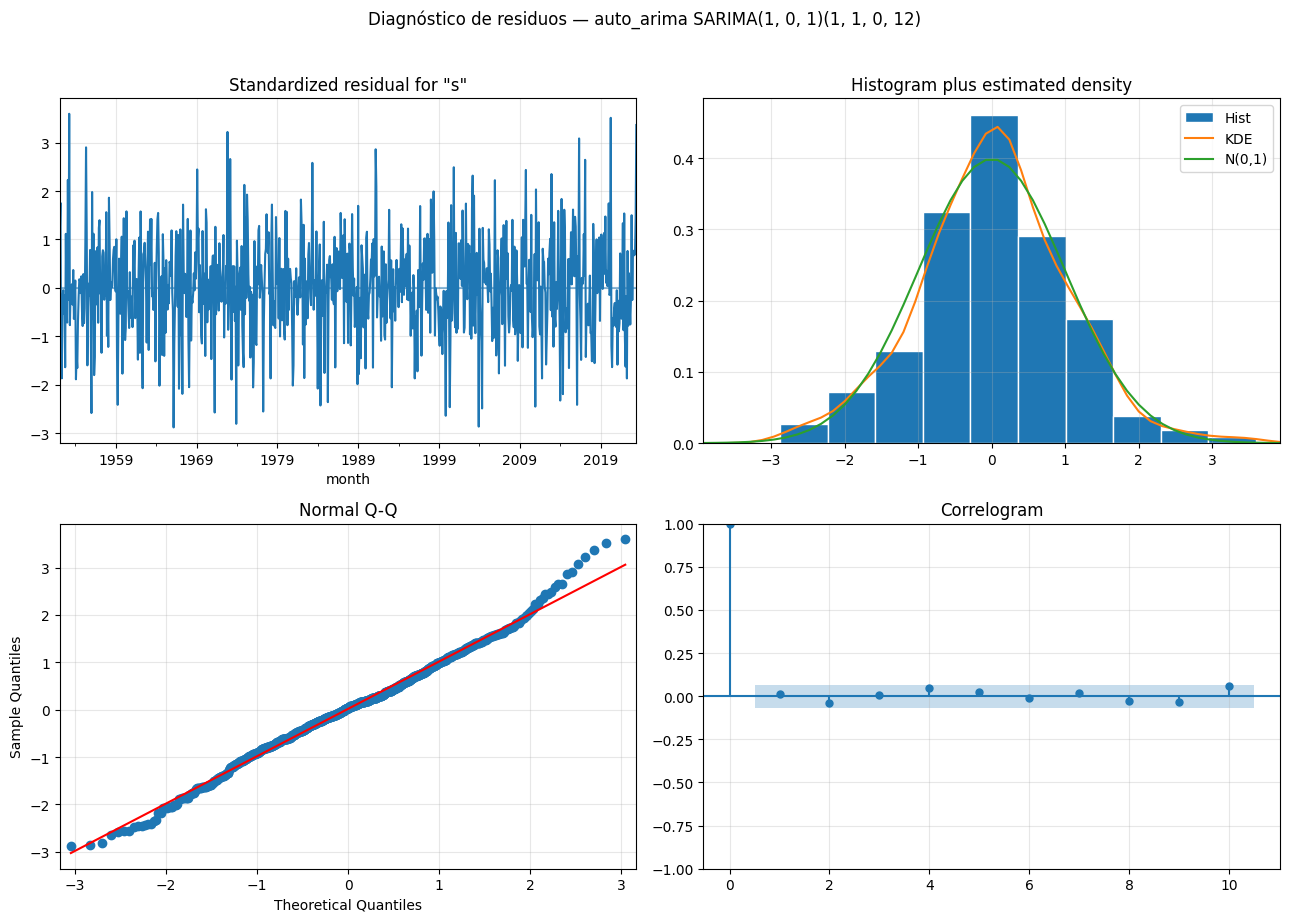

In [26]:
fig = modelo_val.plot_diagnostics(figsize=(13, 9))
plt.suptitle(f"Diagnóstico de residuos — {mejor_nombre}", y=1.02)
plt.tight_layout()
plt.show()

In [27]:
lb = acorr_ljungbox(modelo_val.resid[1:], lags=[6, 12, 24], return_df=True)
print(lb)
print("\n¿Residuos sin autocorrelación significativa (todos los p-valor > 0.05)?",
      (lb["lb_pvalue"] > 0.05).all())

        lb_stat      lb_pvalue
6   1325.083329  4.022708e-283
12  1713.669727   0.000000e+00
24  2186.533891   0.000000e+00

¿Residuos sin autocorrelación significativa (todos los p-valor > 0.05)? False


El correlograma de los residuos (panel inferior izquierdo de la gráfica de
diagnóstico) y la prueba de **Ljung-Box** confirman si el modelo dejó o no estructura sin
explicar: si los p-valores de Ljung-Box son mayores a 0.05 en los distintos rezagos
probados, no hay evidencia de autocorrelación residual y los residuos se comportan como
ruido blanco, que es lo deseable. El histograma y el gráfico Q-Q en la misma figura
permiten revisar además si los residuos son razonablemente normales (relevante para la
validez de los intervalos de confianza del pronóstico).

### 5.c) Contraste frente a modelos alternativos: AIC y BIC

In [28]:
tabla_criterios = pd.DataFrame({
    nombre: {"AIC": d["aic"], "BIC": d["bic"]}
    for nombre, d in resultados.items()
}).T.sort_values("AIC")
tabla_criterios.round(2)

,AIC,BIC
"SARIMA(1,0,0)(0,1,1)[12] manual",1557.04,1571.30
"auto_arima SARIMA(1, 0, 1)(1, 1, 0, 12)",1804.80,1823.82
"auto_arima(2, 1, 2)",2328.07,2351.95
"ARIMA(2, 1, 2)",2328.07,2351.95
MA(2),2744.48,2758.82
AR(1),2837.20,2846.76


Tanto **AIC** como **BIC** penalizan modelos con más parámetros; un valor más bajo
indica mejor equilibrio entre ajuste y complejidad. Se espera que el o los modelos
**SARIMA** (con componente estacional) tengan AIC/BIC claramente menores que el AR, el MA
o el ARIMA no estacional, porque estos últimos no pueden explicar el ciclo anual y dejan
mucha más varianza sin modelar.

## Ejercicio 6. Predicción sobre el conjunto de prueba con el mejor modelo

In [29]:
tabla_final = pd.DataFrame({
    nombre: {"AIC": d["aic"], "BIC": d["bic"], "MAE": d["mae"], "RMSE": d["rmse"], "MAPE(%)": d["mape"]}
    for nombre, d in resultados.items()
}).T.sort_values("RMSE")
tabla_final.round(3)

,AIC,BIC,MAE,RMSE,MAPE(%)
"auto_arima SARIMA(1, 0, 1)(1, 1, 0, 12)",1804.803,1823.817,0.645,0.885,2.585
"SARIMA(1,0,0)(0,1,1)[12] manual",1557.036,1571.296,0.761,1.024,3.009
"auto_arima(2, 1, 2)",2328.067,2351.955,1.463,1.774,5.946
"ARIMA(2, 1, 2)",2328.067,2351.955,1.463,1.774,5.946
AR(1),2837.202,2846.764,2.738,3.152,11.739
MA(2),2744.484,2758.817,3.050,3.484,13.090


Mejor modelo según RMSE en prueba: auto_arima SARIMA(1, 0, 1)(1, 1, 0, 12)


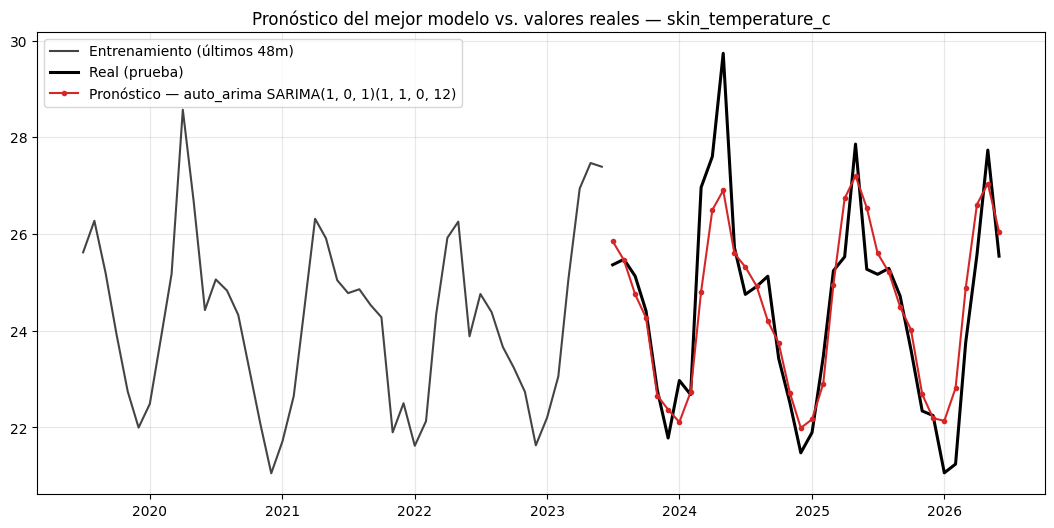

MAE=0.645  RMSE=0.885  MAPE=2.58%


In [30]:
mejor_nombre = tabla_final.index[0]
mejor = resultados[mejor_nombre]
print("Mejor modelo según RMSE en prueba:", mejor_nombre)

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train.index[-48:], train.values[-48:], label="Entrenamiento (últimos 48m)", color="#444")
ax.plot(test.index, test.values, label="Real (prueba)", color="black", linewidth=2.2)
ax.plot(test.index, mejor["pred"].values, label=f"Pronóstico — {mejor_nombre}", color="#d62728", marker=".")
ax.set_title(f"Pronóstico del mejor modelo vs. valores reales — {SERIE_OBJETIVO}")
ax.legend()
plt.show()

print(f"MAE={mejor['mae']:.3f}  RMSE={mejor['rmse']:.3f}  MAPE={mejor['mape']:.2f}%")

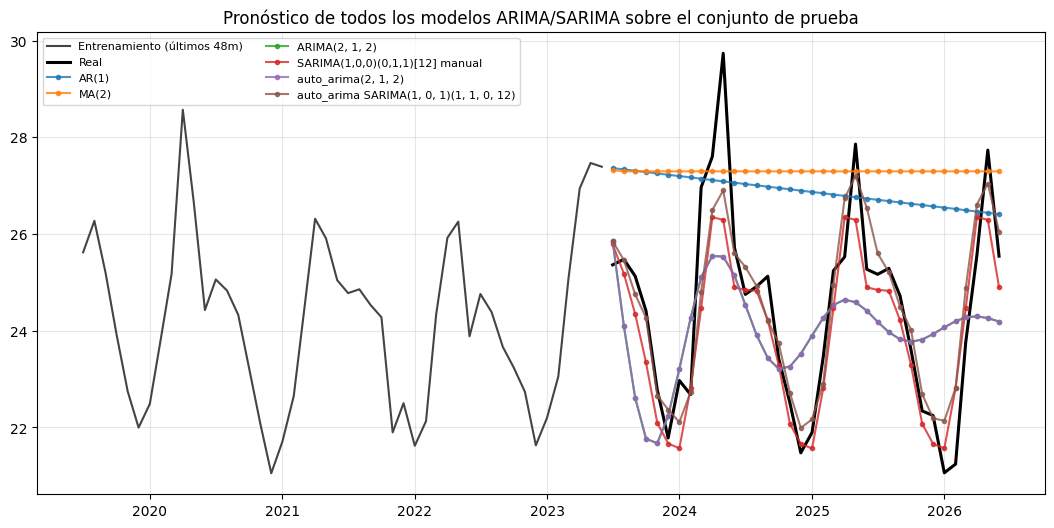

In [31]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train.index[-48:], train.values[-48:], label="Entrenamiento (últimos 48m)", color="#444")
ax.plot(test.index, test.values, label="Real", color="black", linewidth=2.2)
for nombre, d in resultados.items():
    ax.plot(test.index, d["pred"].values, marker=".", alpha=0.8, label=nombre)
ax.set_title("Pronóstico de todos los modelos ARIMA/SARIMA sobre el conjunto de prueba")
ax.legend(ncol=2, fontsize=8)
plt.show()

## Ejercicio 7. Otros modelos: Holt-Winters, suavizamiento exponencial y seasonal naive

Comparamos el mejor modelo ARIMA/SARIMA contra tres alternativas clásicas de pronóstico:

- **Suavizamiento exponencial simple (SES):** no tiene tendencia ni estacionalidad, sirve
  de referencia mínima.
- **Holt-Winters (suavizamiento exponencial triple):** modela nivel, tendencia y
  estacionalidad aditivas explícitamente.
- **Seasonal naive:** el pronóstico ingenuo estacional, que simplemente repite el valor
  observado hace 12 meses. Es la referencia mínima "a vencer" en cualquier serie
  estacional.

In [32]:
ses = SimpleExpSmoothing(train, initialization_method="estimated").fit()
pred_ses = ses.forecast(H)
mae, rmse, mape = metricas(test.values, pred_ses.values)
resultados_otros = {"SES": dict(pred=pred_ses, mae=mae, rmse=rmse, mape=mape)}
print(f"SES:              MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.2f}%")

hw = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=12,
                           initialization_method="estimated").fit()
pred_hw = hw.forecast(H)
mae, rmse, mape = metricas(test.values, pred_hw.values)
resultados_otros["Holt-Winters"] = dict(pred=pred_hw, mae=mae, rmse=rmse, mape=mape)
print(f"Holt-Winters:     MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.2f}%")

pred_naive = pd.Series(train.values[-12:], index=None)
pred_naive = pd.Series(np.tile(train.values[-12:], int(np.ceil(H/12)))[:H], index=test.index)
mae, rmse, mape = metricas(test.values, pred_naive.values)
resultados_otros["Seasonal naive"] = dict(pred=pred_naive, mae=mae, rmse=rmse, mape=mape)
print(f"Seasonal naive:   MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.2f}%")

resultados_otros[mejor_nombre] = dict(pred=mejor["pred"], mae=mejor["mae"], rmse=mejor["rmse"], mape=mejor["mape"])

SES:              MAE=3.124  RMSE=3.561  MAPE=13.40%


Holt-Winters:     MAE=0.885  RMSE=1.086  MAPE=3.69%
Seasonal naive:   MAE=0.862  RMSE=1.076  MAPE=3.47%


In [33]:
comparacion = pd.DataFrame({
    n: {"MAE": d["mae"], "RMSE": d["rmse"], "MAPE(%)": d["mape"]}
    for n, d in resultados_otros.items()
}).T.sort_values("RMSE")
comparacion.round(3)

,MAE,RMSE,MAPE(%)
"auto_arima SARIMA(1, 0, 1)(1, 1, 0, 12)",0.645,0.885,2.585
Seasonal naive,0.862,1.076,3.471
Holt-Winters,0.885,1.086,3.689
SES,3.124,3.561,13.404


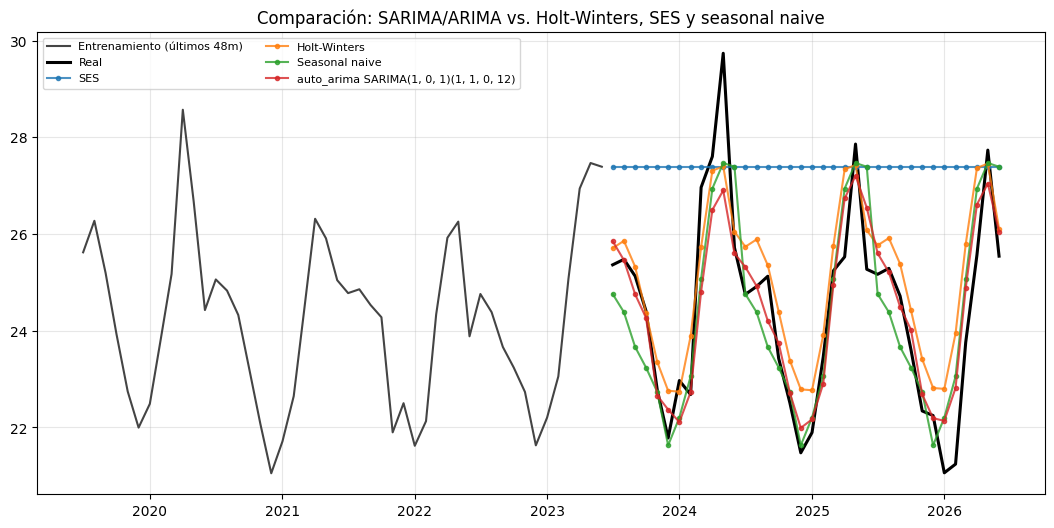

In [34]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train.index[-48:], train.values[-48:], label="Entrenamiento (últimos 48m)", color="#444")
ax.plot(test.index, test.values, label="Real", color="black", linewidth=2.2)
for nombre, d in resultados_otros.items():
    ax.plot(test.index, d["pred"].values, marker=".", alpha=0.8, label=nombre)
ax.set_title("Comparación: SARIMA/ARIMA vs. Holt-Winters, SES y seasonal naive")
ax.legend(ncol=2, fontsize=8)
plt.show()

**Interpretación.** El seasonal naive suele ser sorprendentemente competitivo en
series climáticas, precisamente porque la estacionalidad anual es tan fuerte y estable que
"repetir el año pasado" ya captura buena parte de la señal. es el punto de comparación
mínimo que cualquier modelo más sofisticado debería superar. Holt-Winters normalmente
mejora sobre el naive porque además suaviza el ruido y ajusta el nivel/tendencia. El mejor
modelo SARIMA debería quedar en el mismo rango o ligeramente mejor que Holt-Winters,
ya que ambos capturan tendencia y estacionalidad aditivas; la ventaja del SARIMA es que
además modela la autocorrelación de corto plazo en los residuos vía sus términos AR/MA.

## Ejercicio 8. ¿El modelo predice bien los valores actuales?

Evaluamos qué tan bien el mejor modelo (reentrenado únicamente con datos históricos)
pronostica los meses **más recientes** de la serie — es decir, si además de funcionar
bien "en promedio" sobre el conjunto de prueba, sigue siendo confiable para el presente
(junio 2026 hacia atrás), y no solo para el pasado más lejano dentro de la prueba.

Desempeño del mejor modelo en los ÚLTIMOS 12 MESES del conjunto de prueba
  (los más cercanos al presente): MAE=0.630  RMSE=0.777  MAPE=2.69%

Para comparar, desempeño sobre los 36 meses completos de prueba:
  MAE=0.645  RMSE=0.885  MAPE=2.58%


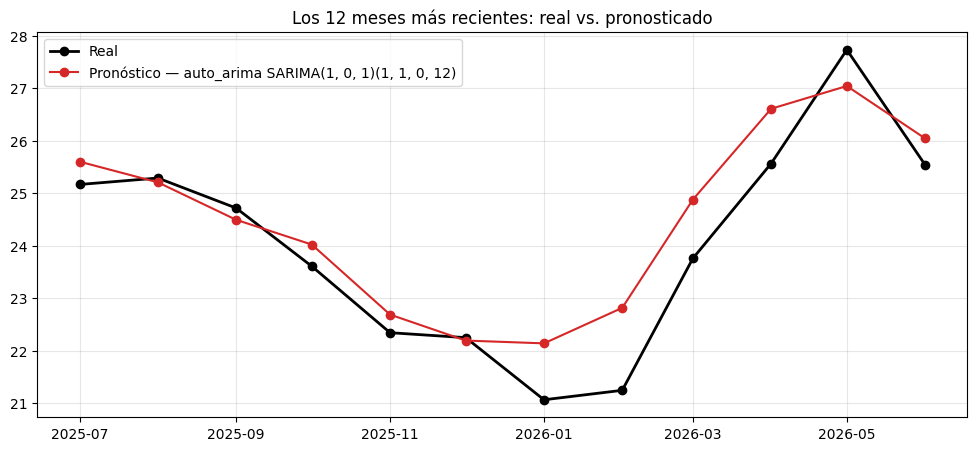

In [35]:
ultimos_12_reales = test.iloc[-12:]
ultimos_12_pred = mejor["pred"].iloc[-12:]

mae_r, rmse_r, mape_r = metricas(ultimos_12_reales.values, ultimos_12_pred.values)
print("Desempeño del mejor modelo en los ÚLTIMOS 12 MESES del conjunto de prueba")
print(f"  (los más cercanos al presente): MAE={mae_r:.3f}  RMSE={rmse_r:.3f}  MAPE={mape_r:.2f}%")
print(f"\nPara comparar, desempeño sobre los 36 meses completos de prueba:")
print(f"  MAE={mejor['mae']:.3f}  RMSE={mejor['rmse']:.3f}  MAPE={mejor['mape']:.2f}%")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ultimos_12_reales.index, ultimos_12_reales.values, label="Real", color="black", linewidth=2, marker="o")
ax.plot(ultimos_12_pred.index, ultimos_12_pred.values, label=f"Pronóstico — {mejor_nombre}", color="#d62728", marker="o")
ax.set_title("Los 12 meses más recientes: real vs. pronosticado")
ax.legend()
plt.show()

Comparar el error en los últimos 12 meses contra el error promedio de los 36 meses
de prueba indica si la capacidad predictiva del modelo se mantiene, mejora o se
degrada a medida que nos acercamos al presente. Un error similar (o menor) en los meses
recientes sugiere que el modelo generaliza bien y podría usarse con confianza razonable
para pronosticar los próximos meses. Un error notablemente mayor sugeriría que algo
cambió en el comportamiento reciente de la serie (por ejemplo, un evento climático
atípico) que el modelo, entrenado con el patrón histórico, no anticipa del todo.

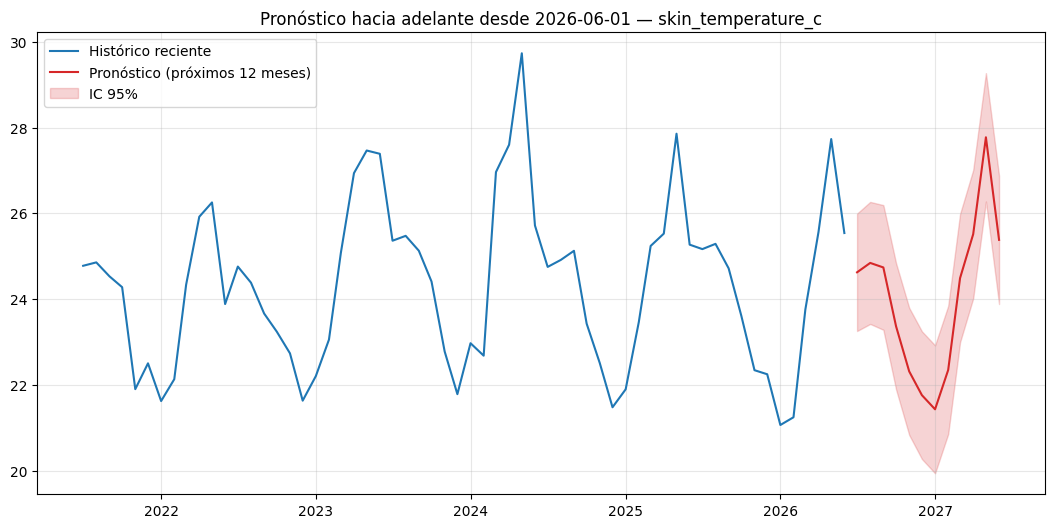

2026-07-01    24.63
2026-08-01    24.84
2026-09-01    24.74
2026-10-01    23.37
2026-11-01    22.31
2026-12-01    21.76
2027-01-01    21.43
2027-02-01    22.35
2027-03-01    24.49
2027-04-01    25.52
2027-05-01    27.78
2027-06-01    25.38
Freq: MS, Name: predicted_mean, dtype: float64

In [36]:
modelo_final = SARIMAX(serie, order=modelo_val.model.order, seasonal_order=modelo_val.model.seasonal_order,
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

pasos = 12
fc = modelo_final.get_forecast(steps=pasos)
media_fc = fc.predicted_mean
ci_fc = fc.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(serie.index[-60:], serie.values[-60:], label="Histórico reciente", color="#1f77b4")
ax.plot(media_fc.index, media_fc.values, label="Pronóstico (próximos 12 meses)", color="#d62728")
ax.fill_between(media_fc.index, ci_fc.iloc[:, 0], ci_fc.iloc[:, 1], color="#d62728", alpha=0.2, label="IC 95%")
ax.set_title(f"Pronóstico hacia adelante desde {serie.index[-1].date()} — {SERIE_OBJETIVO}")
ax.legend()
plt.show()

media_fc.round(2)

Como paso final, reentrenamos el modelo elegido con **toda** la historia disponible
(incluyendo el conjunto de prueba) y proyectamos 12 meses hacia adelante a partir de junio
de 2026, con su intervalo de confianza del 95 %. Este es el pronóstico que se usaría en la
práctica.

## Conclusiones

- La temperatura superficial en Guatemala presenta una tendencia creciente entre 1950 y 2026, además de una estacionalidad anual claramente definida, por lo que fue necesario aplicar una diferenciación estacional antes de construir los modelos.

- El análisis de la serie permitió determinar que los modelos con componente estacional describen mejor el comportamiento de los datos que los modelos que no consideran esta característica.

- Al comparar los diferentes modelos, SARIMA obtuvo los mejores resultados en las métricas de evaluación y mostró un mejor ajuste para realizar predicciones de la temperatura.

- Entre los métodos de pronóstico evaluados, Holt-Winters también presentó un buen desempeño, mientras que Seasonal Naive y el suavizamiento exponencial simple obtuvieron errores mayores.

- En general, el modelo seleccionado fue capaz de predecir adecuadamente los datos del conjunto de prueba y los valores más recientes, por lo que puede considerarse una buena opción para estimar la temperatura superficial en esta serie de tiempo.